In [1]:
# PHASE 1: LIBRARIES & SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib  # For saving the model

# Configuration to display all columns in pandas
pd.set_option('display.max_columns', None)


# PHASE 2: DATA LOADING

print("loading dataset..")
try:
    # Load the dataset 
    df = pd.read_csv('/kaggle/input/real-time-internet-of-things-rt-iot2022/RT_IOT2022.csv')
    print(f"Dataset Loaded Successfully! Shape: {df.shape}")
except FileNotFoundError:
    print("ERROR: File path is incorrect.")
df.head()    

loading dataset..
Dataset Loaded Successfully! Shape: (123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,761.985779,2.972918e+07,3.201160e+07,4.001450e+06,1.040307e+07,4438.877106,1.511694e+06,2.026391e+06,506597.757339,680406.147126,761.985779,2.972918e+07,3.201160e+07,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.282415e+06,2.282415e+06,2.282415e+06,2.282415e+06,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,247.001648,2.985528e+07,3.188358e+07,3.985448e+06,1.046346e+07,4214.048386,1.576436e+06,1.876261e+06,469065.248966,741351.686212,247.001648,2.985528e+07,3.188358e+07,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.028307e+06,2.028307e+06,2.028307e+06,2.028307e+06,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,283.956528,2.984215e+07,3.212405e+07,4.015507e+06,1.044238e+07,2456.903458,1.476049e+06,2.013770e+06,503442.466259,660344.360027,283.956528,2.984215e+07,3.212405e+07,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.281904e+06,2.281904e+06,2.281904e+06,2.281904e+06,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,288.963318,2.991377e+07,3.196106e+07,3.995133e+06,1.048253e+07,3933.906555,1.551892e+06,1.883784e+06,470946.013927,724569.317911,288.963318,2.991377e+07,3.196106e+07,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.047288e+06,2.047288e+06,2.047288e+06,2.047288e+06,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.

In [2]:
# PHASE 3: DATA PREPROCESSING & CLEANING

print("\nStarting Preprocessing...")

# 1. Drop unnecessary columns
# 'Unnamed: 0' is usually an index artifact.
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# 2. Encoding Categorical Features
# Machine Learning models require numerical input. We encode 'proto', 'service', and 'Attack_type'.
le_proto = LabelEncoder()
le_service = LabelEncoder()
le_target = LabelEncoder()

df['proto'] = le_proto.fit_transform(df['proto'])
df['service'] = le_service.fit_transform(df['service'])

# Encoding Target Variable
df['Attack_type_encoded'] = le_target.fit_transform(df['Attack_type'])

# Save the mapping for the Report and API usage
print("\nTarget Variable Mapping")
for index, label in enumerate(le_target.classes_):
    print(f"Class ID {index}: {label}")

# 3. Feature Selection
# We define X (Features) and y (Target).
# We drop the original string 'Attack_type' and the target column from X.
X = df.drop(['Attack_type', 'Attack_type_encoded'], axis=1)
y = df['Attack_type_encoded']


Starting Preprocessing...

Target Variable Mapping
Class ID 0: ARP_poisioning
Class ID 1: DDOS_Slowloris
Class ID 2: DOS_SYN_Hping
Class ID 3: MQTT_Publish
Class ID 4: Metasploit_Brute_Force_SSH
Class ID 5: NMAP_FIN_SCAN
Class ID 6: NMAP_OS_DETECTION
Class ID 7: NMAP_TCP_scan
Class ID 8: NMAP_UDP_SCAN
Class ID 9: NMAP_XMAS_TREE_SCAN
Class ID 10: Thing_Speak
Class ID 11: Wipro_bulb


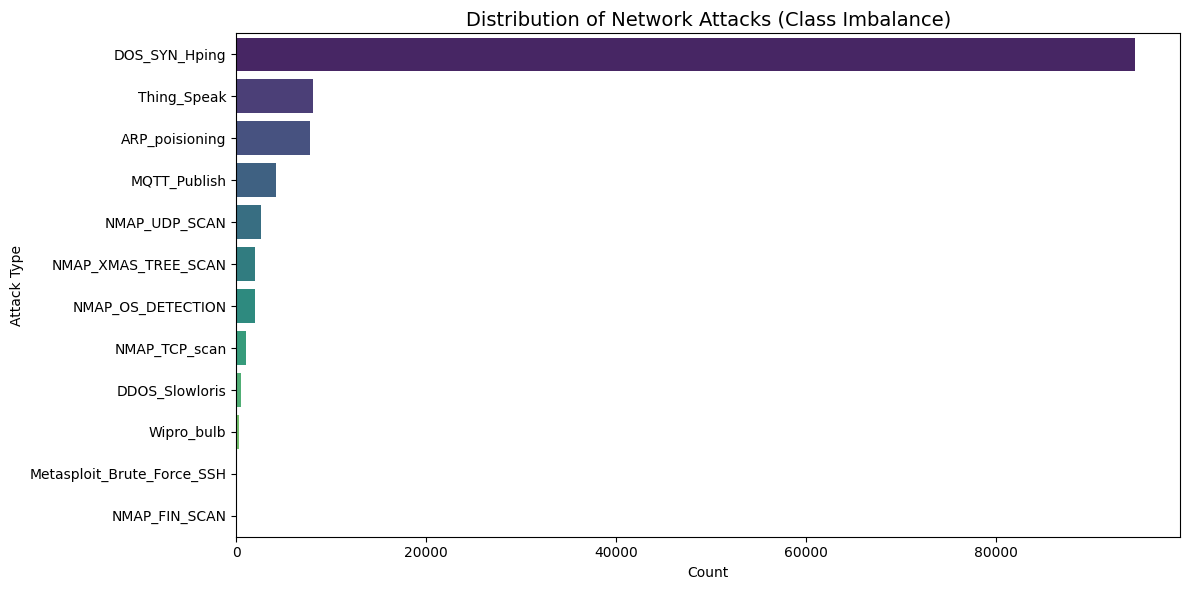

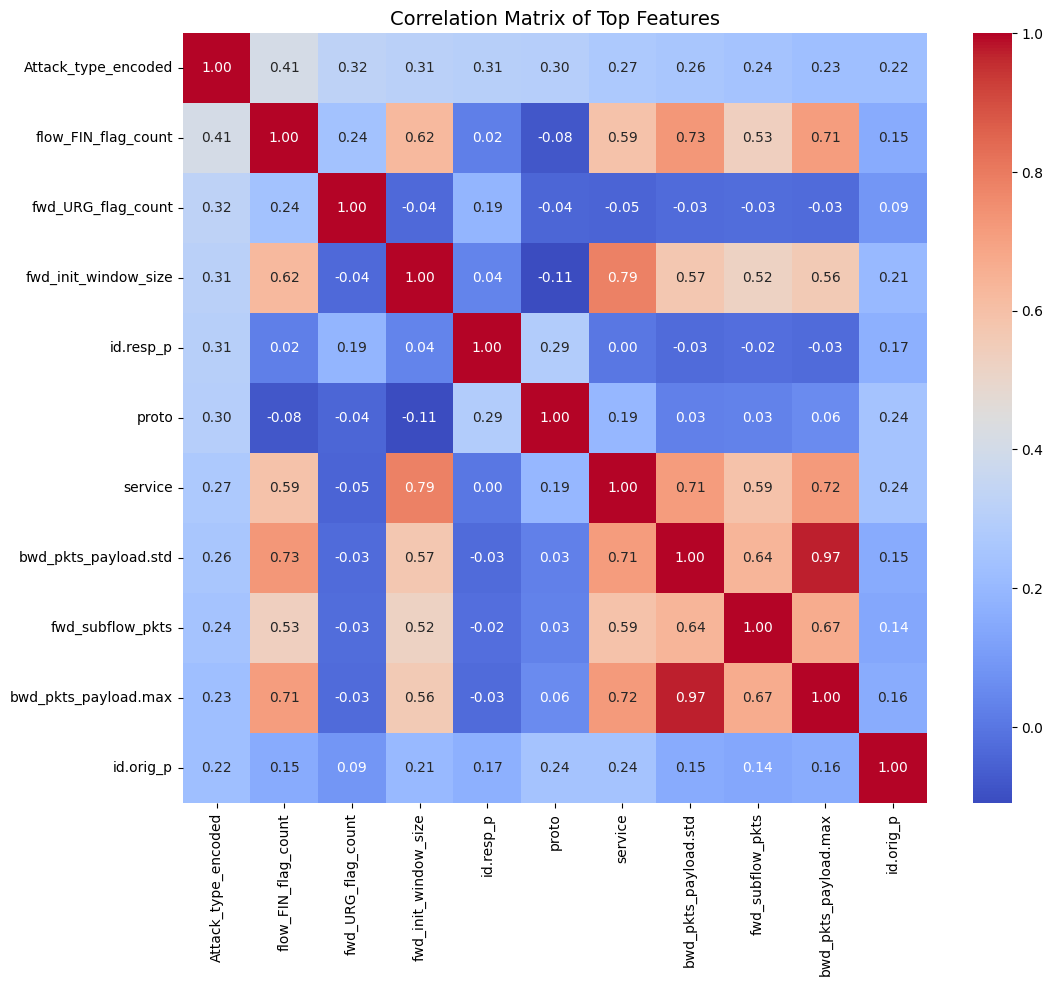

In [3]:
# PHASE 4: EXPLORATORY DATA ANALYSIS (EDA)

# Plot 1: Class Distribution (Imbalance Check)
plt.figure(figsize=(12, 6))
sns.countplot(y='Attack_type', data=df, order=df['Attack_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Network Attacks (Class Imbalance)', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

# Plot 2: Correlation Matrix (Top 10 Features)
# This shows which network features are most related to the Attack Type.
plt.figure(figsize=(12, 10))
# Calculate correlation with the target
corr = df.corr(numeric_only=True)['Attack_type_encoded'].sort_values(ascending=False)
# Select top 10 most positively correlated features
top_features = corr.index[0:11] 
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top Features', fontsize=14)
plt.show()

In [4]:
# PHASE 5: MODEL TRAINING
print("\nStarting Model Training")

# 1. Train-Test Split
# We use 'stratify=y' to maintain the ratio of attack types in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Initialize Random Forest
# We use 'class_weight="balanced"' to handle the dataset imbalance (DoS vs SSH).
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# 3. Fit the model
rf_model.fit(X_train, y_train)
print("model trained successfully!")


Starting Model Training
model trained successfully!



Evaluating model performance
Model Accuracy: 0.9984

 Classification Report
                            precision    recall  f1-score   support

            ARP_poisioning       0.99      0.99      0.99      1550
            DDOS_Slowloris       1.00      0.95      0.98       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.78      1.00      0.88         7
             NMAP_FIN_SCAN       0.83      0.83      0.83         6
         NMAP_OS_DETECTION       1.00      1.00      1.00       400
             NMAP_TCP_scan       1.00      1.00      1.00       200
             NMAP_UDP_SCAN       0.99      0.99      0.99       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.99      0.99      0.99      1622
                Wipro_bulb       0.98      0.98      0.98        51

                  accuracy           

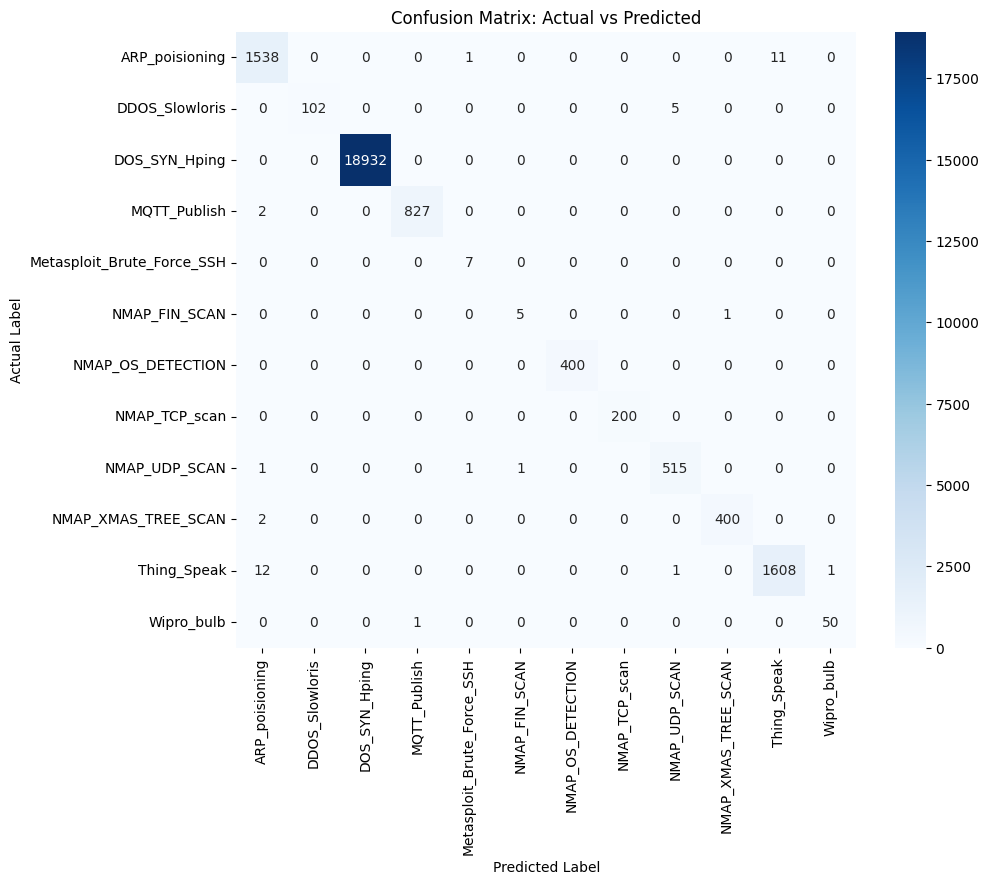

In [5]:
# PHASE 6: EVALUATION

print("\nEvaluating model performance")
y_pred = rf_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.4f}")

# Detailed Report
print("\n Classification Report")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion Matrix Visualization
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Confusion Matrix: Actual vs Predicted')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [6]:
# PHASE 7: EXPORT
# Saving the trained model and the encoder for the FastAPI application.
joblib.dump(rf_model, 'iot_security_model.pkl')
joblib.dump(le_target, 'label_encoder.pkl')
print("saved!")

saved!
